In [1]:
# ============================================================
# STOCKSENSE - ROUND 1
# CELL 1: INSTALL REQUIRED LIBRARIES
# ============================================================

# These libraries will be used throughout Round 1.

!pip install -q pandas numpy matplotlib seaborn scipy statsmodels openpyxl

In [2]:
# ============================================================
# CELL 2: IMPORT LIBRARIES
# ============================================================

import os
import shutil
import zipfile
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm

warnings.filterwarnings("ignore")

# Make pandas display more columns
pd.set_option("display.max_columns", None)

# Make plots look cleaner
sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# ============================================================
# CELL 3: MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

print("Google Drive mounted successfully!")

Mounted at /content/drive
Google Drive mounted successfully!


In [4]:
# ============================================================
# CELL 4: DEFINE PROJECT PATHS
# ============================================================

# Main project folder inside Google Drive
PROJECT_PATH = "/content/drive/MyDrive/STOCKSENSE_TEAM_NEXUS"

# Main folders
RAW_PATH = os.path.join(PROJECT_PATH, "data", "raw")
PROCESSED_PATH = os.path.join(PROJECT_PATH, "data", "processed")
NOTEBOOK_PATH = os.path.join(PROJECT_PATH, "notebooks")
REPORT_PATH = os.path.join(PROJECT_PATH, "reports")
OUTPUT_PATH = os.path.join(PROJECT_PATH, "outputs")
CHART_PATH = os.path.join(OUTPUT_PATH, "charts")
MODEL_PATH = os.path.join(PROJECT_PATH, "models")
SRC_PATH = os.path.join(PROJECT_PATH, "src")

# Create folders if they don't already exist
for folder in [
    RAW_PATH,
    PROCESSED_PATH,
    NOTEBOOK_PATH,
    REPORT_PATH,
    OUTPUT_PATH,
    CHART_PATH,
    MODEL_PATH,
    SRC_PATH
]:
    os.makedirs(folder, exist_ok=True)

print("Project folders are ready!")
print(PROJECT_PATH)

Project folders are ready!
/content/drive/MyDrive/STOCKSENSE_TEAM_NEXUS


In [5]:
# ============================================================
# CELL 5: EXTRACT RAW DATA
# ============================================================

ZIP_PATH = os.path.join(
    PROJECT_PATH,
    "STOCKSENSE_Round1_COMPLETE.zip"
)

# Check whether the ZIP exists
if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(
        "ZIP file not found. Please upload STOCKSENSE_Round1_COMPLETE.zip "
        "to your STOCKSENSE_TEAM_NAME folder in Google Drive."
    )

# Temporary extraction directory
TEMP_EXTRACT = "/content/stocksense_extract"

# Remove previous extraction if it exists
if os.path.exists(TEMP_EXTRACT):
    shutil.rmtree(TEMP_EXTRACT)

# Extract ZIP
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(TEMP_EXTRACT)

print("ZIP extracted successfully!")

ZIP extracted successfully!


In [6]:
# ============================================================
# CELL 6: COPY RAW DATA INTO PROJECT
# ============================================================

# Find the raw folder inside the extracted ZIP
EXTRACTED_RAW = os.path.join(TEMP_EXTRACT, "raw")

# Copy every raw CSV into our project data/raw folder
for file_name in os.listdir(EXTRACTED_RAW):

    source = os.path.join(EXTRACTED_RAW, file_name)
    destination = os.path.join(RAW_PATH, file_name)

    shutil.copy2(source, destination)

print("Raw datasets copied successfully!")

# Display files
print("\nRAW DATA FILES:")
for file_name in os.listdir(RAW_PATH):
    print("✔", file_name)

Raw datasets copied successfully!

RAW DATA FILES:
✔ stores_raw.csv
✔ inventory_raw.csv
✔ external_factors_raw.csv
✔ products_raw.csv
✔ transactions_raw.csv


In [7]:
# ============================================================
# CELL 7: LOAD RAW DATASETS
# ============================================================

transactions = pd.read_csv(
    os.path.join(RAW_PATH, "transactions_raw.csv")
)

products = pd.read_csv(
    os.path.join(RAW_PATH, "products_raw.csv")
)

stores = pd.read_csv(
    os.path.join(RAW_PATH, "stores_raw.csv")
)

inventory = pd.read_csv(
    os.path.join(RAW_PATH, "inventory_raw.csv")
)

external = pd.read_csv(
    os.path.join(RAW_PATH, "external_factors_raw.csv")
)

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [8]:
# ============================================================
# CELL 8: INITIAL DATASET SIZES
# ============================================================

datasets = {
    "Transactions": transactions,
    "Products": products,
    "Stores": stores,
    "Inventory": inventory,
    "External Factors": external
}

for name, df in datasets.items():

    print(f"{name:20s} : {df.shape[0]} rows × {df.shape[1]} columns")

Transactions         : 250 rows × 11 columns
Products             : 250 rows × 8 columns
Stores               : 250 rows × 6 columns
Inventory            : 250 rows × 9 columns
External Factors     : 250 rows × 8 columns


In [9]:
# ============================================================
# CELL 9: INITIAL DATA INSPECTION
# ============================================================

for name, df in datasets.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("\nFirst 5 rows:")
    display(df.head())

    print("\nData types:")
    print(df.dtypes)

    print("\nMissing values:")
    print(df.isnull().sum())

    print("\nDuplicate rows:")
    print(df.duplicated().sum())


Transactions

First 5 rows:


,transaction_id,date,store_id,product_id,quantity,selling_price,discount_pct,promotion_flag,customer_id,payment_mode,hour
0,T1001,2026-08-03,S004,P004,7,409.48,0.0,1,C1098,UPI,18
1,T1002,2026-08-22,S005,P003,4,291.59,0.0,0,C1157,Cash,10
2,T1003,2026-08-15,S012,P024,9,118.50,15.0,1,C1158,Cash,15
3,T1004,2026-08-07,S003,P029,6,22.74,20.0,1,C1151,Cash,14
4,T1005,2026-08-12,S014,P011,5,278.72,0.0,0,C1064,Card,18



Data types:
transaction_id     object
date               object
store_id           object
product_id         object
quantity            int64
selling_price     float64
discount_pct      float64
promotion_flag      int64
customer_id        object
payment_mode       object
hour                int64
dtype: object

Missing values:
transaction_id    0
date              0
store_id          0
product_id        0
quantity          0
selling_price     1
discount_pct      0
promotion_flag    0
customer_id       0
payment_mode      0
hour              0
dtype: int64

Duplicate rows:
1

Products

First 5 rows:


,product_id,category,sub_category,brand,mrp,cost_price,shelf_life_days,supplier_id
0,P001,Frozen,Ice Cream,GlowCare,36.88,23.02,60.0,SUP04
1,P002,Frozen,Ice Cream,FizzUp,305.48,170.64,60.0,SUP08
2,P003,Household,Detergent,PureLife,291.59,216.75,180.0,SUP08
3,P004,Personal Care,Toothpaste,Crispo,409.48,225.93,365.0,SUP14
4,P005,Snacks,Namkeen,CoolBite,98.85,79.92,30.0,SUP03



Data types:
product_id          object
category            object
sub_category        object
brand               object
mrp                float64
cost_price         float64
shelf_life_days    float64
supplier_id         object
dtype: object

Missing values:
product_id         0
category           0
sub_category       0
brand              0
mrp                0
cost_price         0
shelf_life_days    1
supplier_id        0
dtype: int64

Duplicate rows:
1

Stores

First 5 rows:


...


Data types:
store_id               object
city                   object
store_type             object
floor_area_sqft         int64
avg_daily_customers     int64
region                 object
dtype: object

Missing values:
store_id               0
city                   0
store_type             0
floor_area_sqft        0
avg_daily_customers    0
region                 0
dtype: int64

Duplicate rows:
1

Inventory

First 5 rows:


,date,store,product,opening,received,sold,closing,reorder_lvl,lead_days
0,2026-08-03,S004,P004,69,169.0,7,231,102,1
1,2026-08-22,S005,P003,170,114.0,4,280,185,4
2,2026-08-15,S012,P024,306,43.0,9,340,86,7
3,2026-08-07,S003,P029,270,153.0,6,417,66,7
4,2026-08-12,S014,P011,358,46.0,5,399,189,6



Data types:
date            object
store           object
product         object
opening          int64
received       float64
sold             int64
closing          int64
reorder_lvl      int64
lead_days        int64
dtype: object

Missing values:
date           0
store          0
product        0
opening        0
received       1
sold           0
closing        0
reorder_lvl    0
lead_days      0
dtype: int64

Duplicate rows:
0

External Factors

First 5 rows:


,date,city,temp_c,rain_mm,holiday,festival,weekend,local_event
0,2026-08-16,Chennai,31.5,0.2,0,0,1,0
1,2026-08-03,Coimbatore,35.1,0.0,0,0,0,0
2,2026-08-04,Salem,33.2,13.9,0,0,0,0
3,2026-08-21,Tiruppur,25.6,10.1,0,0,0,0
4,2026-08-11,Salem,26.7,0.0,0,0,0,0



Data types:
date            object
city            object
temp_c         float64
rain_mm        float64
holiday          int64
festival         int64
weekend          int64
local_event      int64
dtype: object

Missing values:
date           0
city           0
temp_c         1
rain_mm        0
holiday        0
festival       0
weekend        0
local_event    0
dtype: int64

Duplicate rows:
1


In [10]:
# ============================================================
# CELL 10: TRANSACTION DATA QUALITY AUDIT
# ============================================================

print("TRANSACTION DATA QUALITY CHECK")
print("-" * 50)

print("Duplicate transaction IDs:",
      transactions["transaction_id"].duplicated().sum())

print("Missing values:")
print(transactions.isnull().sum())

print("\nNegative quantities:",
      (transactions["quantity"] < 0).sum())

print("Invalid discount percentages:",
      ((transactions["discount_pct"] < 0) |
       (transactions["discount_pct"] > 100)).sum())

print("Invalid hours:",
      ((transactions["hour"] < 0) |
       (transactions["hour"] > 23)).sum())

print("Invalid selling prices:",
      (transactions["selling_price"] <= 0).sum())

TRANSACTION DATA QUALITY CHECK
--------------------------------------------------
Duplicate transaction IDs: 1
Missing values:
transaction_id    0
date              0
store_id          0
product_id        0
quantity          0
selling_price     1
discount_pct      0
promotion_flag    0
customer_id       0
payment_mode      0
hour              0
dtype: int64

Negative quantities: 1
Invalid discount percentages: 1
Invalid hours: 1
Invalid selling prices: 0


In [11]:
# ============================================================
# CELL 11: CLEAN TRANSACTIONS
# ============================================================

transactions_clean = transactions.copy()

# ------------------------------------------------------------
# 1. Remove duplicate transaction IDs
# ------------------------------------------------------------

transactions_clean = transactions_clean.drop_duplicates(
    subset=["transaction_id"],
    keep="first"
)

# ------------------------------------------------------------
# 2. Remove rows with impossible quantity
# ------------------------------------------------------------

transactions_clean = transactions_clean[
    transactions_clean["quantity"] > 0
]

# ------------------------------------------------------------
# 3. Remove invalid discount percentages
# ------------------------------------------------------------

transactions_clean = transactions_clean[
    (transactions_clean["discount_pct"] >= 0) &
    (transactions_clean["discount_pct"] <= 100)
]

# ------------------------------------------------------------
# 4. Remove invalid transaction hours
# ------------------------------------------------------------

transactions_clean = transactions_clean[
    transactions_clean["hour"].between(0, 23)
]

# ------------------------------------------------------------
# 5. Selling price
# ------------------------------------------------------------

# If selling price is missing, use the median selling price
# instead of deleting the transaction.

transactions_clean["selling_price"] = (
    transactions_clean["selling_price"]
    .fillna(transactions_clean["selling_price"].median())
)

# ------------------------------------------------------------
# 6. Convert date to proper datetime format
# ------------------------------------------------------------

transactions_clean["date"] = pd.to_datetime(
    transactions_clean["date"],
    errors="coerce"
)

# Remove rows where date could not be converted
transactions_clean = transactions_clean.dropna(
    subset=["date"]
)

print("Transactions after cleaning:",
      len(transactions_clean))

display(transactions_clean.head())

Transactions after cleaning: 246


,transaction_id,date,store_id,product_id,quantity,selling_price,discount_pct,promotion_flag,customer_id,payment_mode,hour
0,T1001,2026-08-03,S004,P004,7,409.48,0.0,1,C1098,UPI,18
1,T1002,2026-08-22,S005,P003,4,291.59,0.0,0,C1157,Cash,10
2,T1003,2026-08-15,S012,P024,9,118.50,15.0,1,C1158,Cash,15
3,T1004,2026-08-07,S003,P029,6,22.74,20.0,1,C1151,Cash,14
4,T1005,2026-08-12,S014,P011,5,278.72,0.0,0,C1064,Card,18


In [12]:
# ============================================================
# CELL 12: CLEAN PRODUCTS
# ============================================================

products_clean = products.copy()

# Remove duplicate product IDs
products_clean = products_clean.drop_duplicates(
    subset=["product_id"],
    keep="first"
)

# ------------------------------------------------------------
# Standardise category names
# ------------------------------------------------------------

products_clean["category"] = (
    products_clean["category"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Standardise sub-category
products_clean["sub_category"] = (
    products_clean["sub_category"]
    .astype(str)
    .str.strip()
    .str.title()
)

# Standardise brand
products_clean["brand"] = (
    products_clean["brand"]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# Remove invalid MRP
# ------------------------------------------------------------

products_clean = products_clean[
    products_clean["mrp"] > 0
]

# ------------------------------------------------------------
# Cost price must be positive
# ------------------------------------------------------------

products_clean = products_clean[
    products_clean["cost_price"] > 0
]

# ------------------------------------------------------------
# Cost price should not exceed MRP
# ------------------------------------------------------------

products_clean = products_clean[
    products_clean["cost_price"] <= products_clean["mrp"]
]

# ------------------------------------------------------------
# Fill missing shelf life with median
# ------------------------------------------------------------

products_clean["shelf_life_days"] = (
    products_clean["shelf_life_days"]
    .fillna(products_clean["shelf_life_days"].median())
)

print("Products after cleaning:",
      len(products_clean))

display(products_clean.head())

Products after cleaning: 247


,product_id,category,sub_category,brand,mrp,cost_price,shelf_life_days,supplier_id
0,P001,Frozen,Ice Cream,GlowCare,36.88,23.02,60.0,SUP04
1,P002,Frozen,Ice Cream,FizzUp,305.48,170.64,60.0,SUP08
2,P003,Household,Detergent,PureLife,291.59,216.75,180.0,SUP08
3,P004,Personal Care,Toothpaste,Crispo,409.48,225.93,365.0,SUP14
4,P005,Snacks,Namkeen,CoolBite,98.85,79.92,30.0,SUP03


In [13]:
# ============================================================
# CELL 13: CLEAN STORES
# ============================================================

stores_clean = stores.copy()

# Remove duplicate store IDs
stores_clean = stores_clean.drop_duplicates(
    subset=["store_id"],
    keep="first"
)

# ------------------------------------------------------------
# Standardise text columns
# ------------------------------------------------------------

for column in ["city", "store_type", "region"]:

    stores_clean[column] = (
        stores_clean[column]
        .astype(str)
        .str.strip()
        .str.title()
    )

# ------------------------------------------------------------
# Remove impossible floor area
# ------------------------------------------------------------

stores_clean = stores_clean[
    stores_clean["floor_area_sqft"] > 0
]

# ------------------------------------------------------------
# Remove impossible customer counts
# ------------------------------------------------------------

stores_clean = stores_clean[
    stores_clean["avg_daily_customers"] > 0
]

print("Stores after cleaning:",
      len(stores_clean))

display(stores_clean.head())

Stores after cleaning: 247


,store_id,city,store_type,floor_area_sqft,avg_daily_customers,region
0,S001,Trichy,Express,4439,534,Central
1,S002,Salem,Hypermarket,24793,4197,Central
2,S003,Erode,Hypermarket,18029,3086,West
3,S004,Bengaluru,Hypermarket,15060,2340,South
4,S005,Erode,Express,5478,734,West


In [14]:
# ============================================================
# CELL 14: CLEAN INVENTORY
# ============================================================

inventory_clean = inventory.copy()

# Convert date
inventory_clean["date"] = pd.to_datetime(
    inventory_clean["date"],
    errors="coerce"
)

# ------------------------------------------------------------
# Remove duplicate Store + Product + Date records
# ------------------------------------------------------------

inventory_clean = inventory_clean.drop_duplicates(
    subset=["date", "store", "product"],
    keep="first"
)

# ------------------------------------------------------------
# Fill missing received quantity
# ------------------------------------------------------------

inventory_clean["received"] = (
    inventory_clean["received"].fillna(0)
)

# ------------------------------------------------------------
# Remove negative inventory quantities
# ------------------------------------------------------------

quantity_columns = [
    "opening",
    "received",
    "sold",
    "closing",
    "reorder_lvl"
]

for column in quantity_columns:

    inventory_clean = inventory_clean[
        inventory_clean[column] >= 0
    ]

# ------------------------------------------------------------
# Validate inventory arithmetic
# ------------------------------------------------------------

inventory_clean["calculated_closing"] = (
    inventory_clean["opening"]
    + inventory_clean["received"]
    - inventory_clean["sold"]
)

inventory_clean["inventory_mismatch_flag"] = (
    inventory_clean["closing"] !=
    inventory_clean["calculated_closing"]
)

# ------------------------------------------------------------
# Reconcile incorrect closing stock
# ------------------------------------------------------------

inventory_clean.loc[
    inventory_clean["inventory_mismatch_flag"],
    "closing"
] = inventory_clean.loc[
    inventory_clean["inventory_mismatch_flag"],
    "calculated_closing"
]

# Remove helper column
inventory_clean.drop(
    columns=["calculated_closing"],
    inplace=True
)

print("Inventory after cleaning:",
      len(inventory_clean))

display(inventory_clean.head())

Inventory after cleaning: 246


,date,store,product,opening,received,sold,closing,reorder_lvl,lead_days,inventory_mismatch_flag
0,2026-08-03,S004,P004,69,169.0,7,231,102,1,False
1,2026-08-22,S005,P003,170,114.0,4,280,185,4,False
2,2026-08-15,S012,P024,306,43.0,9,340,86,7,False
3,2026-08-07,S003,P029,270,153.0,6,417,66,7,False
4,2026-08-12,S014,P011,358,46.0,5,399,189,6,False


In [15]:
# ============================================================
# CELL 15: CLEAN EXTERNAL FACTORS
# ============================================================

external_clean = external.copy()

# Convert date
external_clean["date"] = pd.to_datetime(
    external_clean["date"],
    errors="coerce"
)

# Standardise city
external_clean["city"] = (
    external_clean["city"]
    .astype(str)
    .str.strip()
    .str.title()
)

# ------------------------------------------------------------
# Temperature
# ------------------------------------------------------------

external_clean["temp_c"] = (
    external_clean["temp_c"]
    .fillna(external_clean["temp_c"].median())
)

# ------------------------------------------------------------
# Rainfall cannot be negative
# ------------------------------------------------------------

external_clean.loc[
    external_clean["rain_mm"] < 0,
    "rain_mm"
] = np.nan

external_clean["rain_mm"] = (
    external_clean["rain_mm"].fillna(0)
)

# ------------------------------------------------------------
# Weekend must be either 0 or 1
# ------------------------------------------------------------

external_clean.loc[
    ~external_clean["weekend"].isin([0, 1]),
    "weekend"
] = np.nan

external_clean["weekend"] = (
    external_clean["weekend"].fillna(0).astype(int)
)

print("External factors after cleaning:",
      len(external_clean))

display(external_clean.head())

External factors after cleaning: 250


,date,city,temp_c,rain_mm,holiday,festival,weekend,local_event
0,2026-08-16,Chennai,31.5,0.2,0,0,1,0
1,2026-08-03,Coimbatore,35.1,0.0,0,0,0,0
2,2026-08-04,Salem,33.2,13.9,0,0,0,0
3,2026-08-21,Tiruppur,25.6,10.1,0,0,0,0
4,2026-08-11,Salem,26.7,0.0,0,0,0,0


In [16]:
# ============================================================
# CELL 16: CLEANED DATASET VALIDATION
# ============================================================

cleaned_datasets = {
    "Transactions": transactions_clean,
    "Products": products_clean,
    "Stores": stores_clean,
    "Inventory": inventory_clean,
    "External Factors": external_clean
}

print("CLEANED DATASET SUMMARY")
print("=" * 60)

for name, df in cleaned_datasets.items():

    print(
        f"{name:20s} : "
        f"{len(df):3d} rows × {df.shape[1]:2d} columns"
    )

CLEANED DATASET SUMMARY
Transactions         : 246 rows × 11 columns
Products             : 247 rows ×  8 columns
Stores               : 247 rows ×  6 columns
Inventory            : 246 rows × 10 columns
External Factors     : 250 rows ×  8 columns


In [17]:
# ============================================================
# CELL 17: SAVE CLEANED DATASETS
# ============================================================

transactions_clean.to_csv(
    os.path.join(PROCESSED_PATH, "transactions_clean.csv"),
    index=False
)

products_clean.to_csv(
    os.path.join(PROCESSED_PATH, "products_clean.csv"),
    index=False
)

stores_clean.to_csv(
    os.path.join(PROCESSED_PATH, "stores_clean.csv"),
    index=False
)

inventory_clean.to_csv(
    os.path.join(PROCESSED_PATH, "inventory_clean.csv"),
    index=False
)

external_clean.to_csv(
    os.path.join(PROCESSED_PATH, "external_factors_clean.csv"),
    index=False
)

print("All cleaned datasets saved successfully!")

All cleaned datasets saved successfully!


In [18]:
# ============================================================
# CELL 18: DATA QUALITY REPORT
# ============================================================

quality_report = []

def add_quality_issue(dataset, issue, count, action):

    quality_report.append({
        "dataset": dataset,
        "issue": issue,
        "count": count,
        "action_taken": action
    })


# ------------------------------------------------------------
# TRANSACTIONS
# ------------------------------------------------------------

add_quality_issue(
    "transactions",
    "Duplicate transaction IDs",
    transactions["transaction_id"].duplicated().sum(),
    "Removed duplicate transaction records"
)

add_quality_issue(
    "transactions",
    "Negative quantity",
    (transactions["quantity"] < 0).sum(),
    "Removed invalid sales quantities"
)

add_quality_issue(
    "transactions",
    "Invalid discount percentage",
    ((transactions["discount_pct"] < 0) |
     (transactions["discount_pct"] > 100)).sum(),
    "Removed invalid discount records"
)

add_quality_issue(
    "transactions",
    "Invalid transaction hour",
    ((transactions["hour"] < 0) |
     (transactions["hour"] > 23)).sum(),
    "Removed records with invalid hour"
)

add_quality_issue(
    "transactions",
    "Missing selling price",
    transactions["selling_price"].isna().sum(),
    "Filled using median selling price"
)


# ------------------------------------------------------------
# PRODUCTS
# ------------------------------------------------------------

add_quality_issue(
    "products",
    "Duplicate product IDs",
    products["product_id"].duplicated().sum(),
    "Removed duplicate products"
)

add_quality_issue(
    "products",
    "Invalid MRP",
    (products["mrp"] <= 0).sum(),
    "Removed invalid products"
)

add_quality_issue(
    "products",
    "Cost price greater than MRP",
    (products["cost_price"] > products["mrp"]).sum(),
    "Removed economically invalid records"
)

add_quality_issue(
    "products",
    "Missing shelf life",
    products["shelf_life_days"].isna().sum(),
    "Filled using median shelf life"
)


# ------------------------------------------------------------
# STORES
# ------------------------------------------------------------

add_quality_issue(
    "stores",
    "Duplicate store IDs",
    stores["store_id"].duplicated().sum(),
    "Removed duplicate stores"
)

add_quality_issue(
    "stores",
    "Invalid floor area",
    (stores["floor_area_sqft"] <= 0).sum(),
    "Removed invalid store records"
)

add_quality_issue(
    "stores",
    "Invalid customer count",
    (stores["avg_daily_customers"] <= 0).sum(),
    "Removed invalid store records"
)


# ------------------------------------------------------------
# INVENTORY
# ------------------------------------------------------------

add_quality_issue(
    "inventory",
    "Duplicate date-store-product",
    inventory.duplicated(
        subset=["date", "store", "product"]
    ).sum(),
    "Removed duplicate inventory records"
)

add_quality_issue(
    "inventory",
    "Missing received quantity",
    inventory["received"].isna().sum(),
    "Replaced missing received quantity with 0"
)

add_quality_issue(
    "inventory",
    "Inventory arithmetic mismatch",
    (
        inventory["closing"] !=
        inventory["opening"] +
        inventory["received"].fillna(0) -
        inventory["sold"]
    ).sum(),
    "Reconciled closing stock using inventory arithmetic"
)


# ------------------------------------------------------------
# EXTERNAL FACTORS
# ------------------------------------------------------------

add_quality_issue(
    "external_factors",
    "Missing temperature",
    external["temp_c"].isna().sum(),
    "Filled using median temperature"
)

add_quality_issue(
    "external_factors",
    "Negative rainfall",
    (external["rain_mm"] < 0).sum(),
    "Replaced invalid rainfall with 0"
)

add_quality_issue(
    "external_factors",
    "Invalid weekend flag",
    (~external["weekend"].isin([0, 1])).sum(),
    "Replaced invalid value with 0"
)


# Convert list into DataFrame
quality_report_df = pd.DataFrame(quality_report)

# Save report
quality_report_df.to_csv(
    os.path.join(
        REPORT_PATH,
        "data_quality_report.csv"
    ),
    index=False
)

display(quality_report_df)

,dataset,issue,count,action_taken
0,transactions,Duplicate transaction IDs,1,Removed duplicate transaction records
1,transactions,Negative quantity,1,Removed invalid sales quantities
2,transactions,Invalid discount percentage,1,Removed invalid discount records
3,transactions,Invalid transaction hour,1,Removed records with invalid hour
4,transactions,Missing selling price,1,Filled using median selling price
5,products,Duplicate product IDs,1,Removed duplicate products
6,products,Invalid MRP,1,Removed invalid products
7,products,Cost price greater than MRP,2,Removed economically invalid records
8,products,Missing shelf life,1,Filled using median shelf life
9,stores,Duplicate store IDs,1,Removed duplicate stores


In [19]:
# ============================================================
# CELL 19: AGGREGATE TRANSACTIONS TO DAILY STORE × PRODUCT
# ============================================================

daily_sales = (
    transactions_clean
    .groupby(
        ["date", "store_id", "product_id"],
        as_index=False
    )
    .agg(
        units_sold=("quantity", "sum"),
        avg_selling_price=("selling_price", "mean"),
        avg_discount_pct=("discount_pct", "mean"),
        promotion_flag=("promotion_flag", "max"),
        transaction_count=("transaction_id", "count")
    )
)

# Calculate revenue
daily_sales["revenue"] = (
    daily_sales["units_sold"] *
    daily_sales["avg_selling_price"]
)

print("Daily sales shape:",
      daily_sales.shape)

display(daily_sales.head())

Daily sales shape: (245, 9)


,date,store_id,product_id,units_sold,avg_selling_price,avg_discount_pct,promotion_flag,transaction_count,revenue
0,2026-08-01,S002,P028,4,142.76,0.0,0,1,571.04
1,2026-08-01,S008,P012,6,350.19,0.0,0,1,2101.14
2,2026-08-01,S011,P020,11,62.39,20.0,1,1,686.29
3,2026-08-01,S014,P001,8,36.88,0.0,1,1,295.04
4,2026-08-01,S014,P003,11,247.85,15.0,1,1,2726.35


In [20]:
# ============================================================
# CELL 20: PREPARE INVENTORY FOR MERGING
# ============================================================

inventory_merge = inventory_clean.copy()

# Rename columns so they match our master dataset
inventory_merge = inventory_merge.rename(
    columns={
        "store": "store_id",
        "product": "product_id"
    }
)

print(inventory_merge.shape)

display(inventory_merge.head())

(246, 10)


,date,store_id,product_id,opening,received,sold,closing,reorder_lvl,lead_days,inventory_mismatch_flag
0,2026-08-03,S004,P004,69,169.0,7,231,102,1,False
1,2026-08-22,S005,P003,170,114.0,4,280,185,4,False
2,2026-08-15,S012,P024,306,43.0,9,340,86,7,False
3,2026-08-07,S003,P029,270,153.0,6,417,66,7,False
4,2026-08-12,S014,P011,358,46.0,5,399,189,6,False


In [21]:
# ============================================================
# CELL 21: PREPARE EXTERNAL FACTORS
# ============================================================

# Aggregate external factors to one DATE × CITY record.
# This prevents duplicate rows during the master merge.

external_merge = (
    external_clean
    .groupby(
        ["date", "city"],
        as_index=False
    )
    .agg(
        temp_c=("temp_c", "mean"),
        rain_mm=("rain_mm", "mean"),
        holiday=("holiday", "max"),
        festival=("festival", "max"),
        weekend=("weekend", "max"),
        local_event=("local_event", "max")
    )
)

print("External merge table:",
      external_merge.shape)

display(external_merge.head())

External merge table: (143, 8)


,date,city,temp_c,rain_mm,holiday,festival,weekend,local_event
0,2026-08-01,Bengaluru,25.9,0.0,1,0,1,0
1,2026-08-01,Coimbatore,27.7,0.0,0,0,1,0
2,2026-08-01,Erode,25.9,2.7,0,0,1,0
3,2026-08-01,Madurai,27.1,6.5,0,0,1,0
4,2026-08-01,Tiruppur,35.2,12.8,0,0,1,0


In [22]:
# ============================================================
# CELL 22: MERGE SALES WITH PRODUCT DATA
# ============================================================

master = daily_sales.merge(
    products_clean,
    on="product_id",
    how="left"
)

print("After product merge:",
      master.shape)

display(master.head())

After product merge: (245, 16)


,date,store_id,product_id,units_sold,avg_selling_price,avg_discount_pct,promotion_flag,transaction_count,revenue,category,sub_category,brand,mrp,cost_price,shelf_life_days,supplier_id
0,2026-08-01,S002,P028,4,142.76,0.0,0,1,571.04,Personal Care,Shampoo,Aavin,142.76,80.99,240.0,SUP18
1,2026-08-01,S008,P012,6,350.19,0.0,0,1,2101.14,Frozen,Frozen Snacks,Aavin,350.19,272.30,60.0,SUP02
2,2026-08-01,S011,P020,11,62.39,20.0,1,1,686.29,Grocery,Oil,NovaFresh,77.99,52.05,30.0,SUP09
3,2026-08-01,S014,P001,8,36.88,0.0,1,1,295.04,Frozen,Ice Cream,GlowCare,36.88,23.02,60.0,SUP04
4,2026-08-01,S014,P003,11,247.85,15.0,1,1,2726.35,Household,Detergent,PureLife,291.59,216.75,180.0,SUP08


In [23]:
# ============================================================
# CELL 23: MERGE STORE DATA
# ============================================================

master = master.merge(
    stores_clean,
    on="store_id",
    how="left"
)

print("After store merge:",
      master.shape)

display(master.head())

After store merge: (245, 21)


,date,store_id,product_id,units_sold,avg_selling_price,avg_discount_pct,promotion_flag,transaction_count,revenue,category,sub_category,brand,mrp,cost_price,shelf_life_days,supplier_id,city,store_type,floor_area_sqft,avg_daily_customers,region
0,2026-08-01,S002,P028,4,142.76,0.0,0,1,571.04,Personal Care,Shampoo,Aavin,142.76,80.99,240.0,SUP18,Salem,Hypermarket,24793.0,4197.0,Central
1,2026-08-01,S008,P012,6,350.19,0.0,0,1,2101.14,Frozen,Frozen Snacks,Aavin,350.19,272.30,60.0,SUP02,Tiruppur,Supermarket,10650.0,1446.0,West
2,2026-08-01,S011,P020,11,62.39,20.0,1,1,686.29,Grocery,Oil,NovaFresh,77.99,52.05,30.0,SUP09,Madurai,Supermarket,6169.0,1002.0,South
3,2026-08-01,S014,P001,8,36.88,0.0,1,1,295.04,Frozen,Ice Cream,GlowCare,36.88,23.02,60.0,SUP04,NaN,NaN,NaN,NaN,NaN
4,2026-08-01,S014,P003,11,247.85,15.0,1,1,2726.35,Household,Detergent,PureLife,291.59,216.75,180.0,SUP08,NaN,NaN,NaN,NaN,NaN


In [24]:
# ============================================================
# CELL 24: MERGE INVENTORY DATA
# ============================================================

master = master.merge(
    inventory_merge,
    on=["date", "store_id", "product_id"],
    how="left"
)

print("After inventory merge:",
      master.shape)

After inventory merge: (245, 28)


In [25]:
# ============================================================
# CELL 25: MERGE EXTERNAL FACTORS
# ============================================================

master = master.merge(
    external_merge,
    on=["date", "city"],
    how="left"
)

print("Final master shape:",
      master.shape)

display(master.head())

Final master shape: (245, 34)


,date,store_id,product_id,units_sold,avg_selling_price,avg_discount_pct,promotion_flag,transaction_count,revenue,category,sub_category,brand,mrp,cost_price,shelf_life_days,supplier_id,city,store_type,floor_area_sqft,avg_daily_customers,region,opening,received,sold,closing,reorder_lvl,lead_days,inventory_mismatch_flag,temp_c,rain_mm,holiday,festival,weekend,local_event
0,2026-08-01,S002,P028,4,142.76,0.0,0,1,571.04,Personal Care,Shampoo,Aavin,142.76,80.99,240.0,SUP18,Salem,Hypermarket,24793.0,4197.0,Central,338.0,104.0,4.0,438.0,95.0,2.0,False,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-08-01,S008,P012,6,350.19,0.0,0,1,2101.14,Frozen,Frozen Snacks,Aavin,350.19,272.30,60.0,SUP02,Tiruppur,Supermarket,10650.0,1446.0,West,263.0,25.0,6.0,282.0,71.0,1.0,False,35.2,12.8,0.0,0.0,1.0,0.0
2,2026-08-01,S011,P020,11,62.39,20.0,1,1,686.29,Grocery,Oil,NovaFresh,77.99,52.05,30.0,SUP09,Madurai,Supermarket,6169.0,1002.0,South,325.0,3.0,11.0,317.0,47.0,1.0,False,27.1,6.5,0.0,0.0,1.0,0.0
3,2026-08-01,S014,P001,8,36.88,0.0,1,1,295.04,Frozen,Ice Cream,GlowCare,36.88,23.02,60.0,SUP04,NaN,NaN,NaN,NaN,NaN,164.0,0.0,8.0,156.0,171.0,7.0,True,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-08-01,S014,P003,11,247.85,15.0,1,1,2726.35,Household,Detergent,PureLife,291.59,216.75,180.0,SUP08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# ============================================================
# CELL 26: MASTER DATA VALIDATION
# ============================================================

print("MASTER DATA VALIDATION")
print("=" * 60)

# ------------------------------------------------------------
# Number of rows
# ------------------------------------------------------------

print("Rows:", len(master))

# ------------------------------------------------------------
# Number of columns
# ------------------------------------------------------------

print("Columns:", master.shape[1])

# ------------------------------------------------------------
# Duplicate Store × Product × Date
# ------------------------------------------------------------

duplicate_keys = master.duplicated(
    subset=["date", "store_id", "product_id"]
).sum()

print(
    "Duplicate Date × Store × Product:",
    duplicate_keys
)

# ------------------------------------------------------------
# Missing values
# ------------------------------------------------------------

print("\nMissing values:")
display(
    master.isnull().sum()
    .sort_values(ascending=False)
    .head(15)
)

MASTER DATA VALIDATION
Rows: 245
Columns: 34
Duplicate Date × Store × Product: 0

Missing values:


,0
local_event,110
weekend,110
festival,110
holiday,110
rain_mm,110
temp_c,110
avg_daily_customers,23
floor_area_sqft,23
store_type,23
city,23


In [27]:
# ============================================================
# CELL 27: CREATE STOCK-OUT FLAG
# ============================================================

# Stock-out is considered to have occurred when:
# closing stock is zero OR
# inventory is below the reorder level.

master["stockout_flag"] = (
    (master["closing"] <= 0) |
    (master["closing"] < master["reorder_lvl"])
).astype(int)

print(
    "Stock-out observations:",
    master["stockout_flag"].sum()
)

print(
    "Stock-out rate:",
    round(master["stockout_flag"].mean() * 100, 2),
    "%"
)

Stock-out observations: 7
Stock-out rate: 2.86 %


In [28]:
# ============================================================
# CELL 28: CREATE INVENTORY FEATURES
# ============================================================

# Avoid division by zero
master["avg_daily_demand"] = (
    master["units_sold"].replace(0, np.nan)
)

# Days of inventory
master["days_of_inventory"] = (
    master["closing"] /
    master["avg_daily_demand"]
)

# Inventory to demand ratio
master["inventory_to_demand_ratio"] = (
    master["closing"] /
    master["units_sold"].replace(0, np.nan)
)

# Replace infinite values
master = master.replace(
    [np.inf, -np.inf],
    np.nan
)

# Fill undefined ratios with 0
master["days_of_inventory"] = (
    master["days_of_inventory"].fillna(0)
)

master["inventory_to_demand_ratio"] = (
    master["inventory_to_demand_ratio"].fillna(0)
)

display(
    master[
        [
            "date",
            "store_id",
            "product_id",
            "units_sold",
            "closing",
            "reorder_lvl",
            "stockout_flag",
            "days_of_inventory"
        ]
    ].head()
)

,date,store_id,product_id,units_sold,closing,reorder_lvl,stockout_flag,days_of_inventory
0,2026-08-01,S002,P028,4,438.0,95.0,0,109.500000
1,2026-08-01,S008,P012,6,282.0,71.0,0,47.000000
2,2026-08-01,S011,P020,11,317.0,47.0,0,28.818182
3,2026-08-01,S014,P001,8,156.0,171.0,1,19.500000
4,2026-08-01,S014,P003,11,NaN,NaN,0,0.000000


In [29]:
# ============================================================
# CELL 29: CREATE TIME FEATURES
# ============================================================

master["day_of_week"] = master["date"].dt.dayofweek

master["day_name"] = master["date"].dt.day_name()

master["month"] = master["date"].dt.month

master["week_no"] = master["date"].dt.isocalendar().week.astype(int)

# Monday-Friday = Weekday
# Saturday-Sunday = Weekend
master["weekend_flag"] = (
    master["day_of_week"] >= 5
).astype(int)

display(
    master[
        [
            "date",
            "day_name",
            "month",
            "week_no",
            "weekend_flag"
        ]
    ].head()
)

,date,day_name,month,week_no,weekend_flag
0,2026-08-01,Saturday,8,31,1
1,2026-08-01,Saturday,8,31,1
2,2026-08-01,Saturday,8,31,1
3,2026-08-01,Saturday,8,31,1
4,2026-08-01,Saturday,8,31,1


In [30]:
# ============================================================
# CELL 30: SAVE MASTER DATASET
# ============================================================

MASTER_FILE = os.path.join(
    PROCESSED_PATH,
    "master_cleaned.csv"
)

master.to_csv(
    MASTER_FILE,
    index=False
)

print("Master dataset saved!")
print(MASTER_FILE)
print("Shape:", master.shape)

Master dataset saved!
/content/drive/MyDrive/STOCKSENSE_TEAM_NEXUS/data/processed/master_cleaned.csv
Shape: (245, 43)


,category,revenue
3,Grocery,125565.40
0,Beverages,57612.49
4,Household,52582.89
5,Personal Care,51827.29
2,Frozen,27659.45
1,Dairy,12841.48
6,Snacks,12326.35


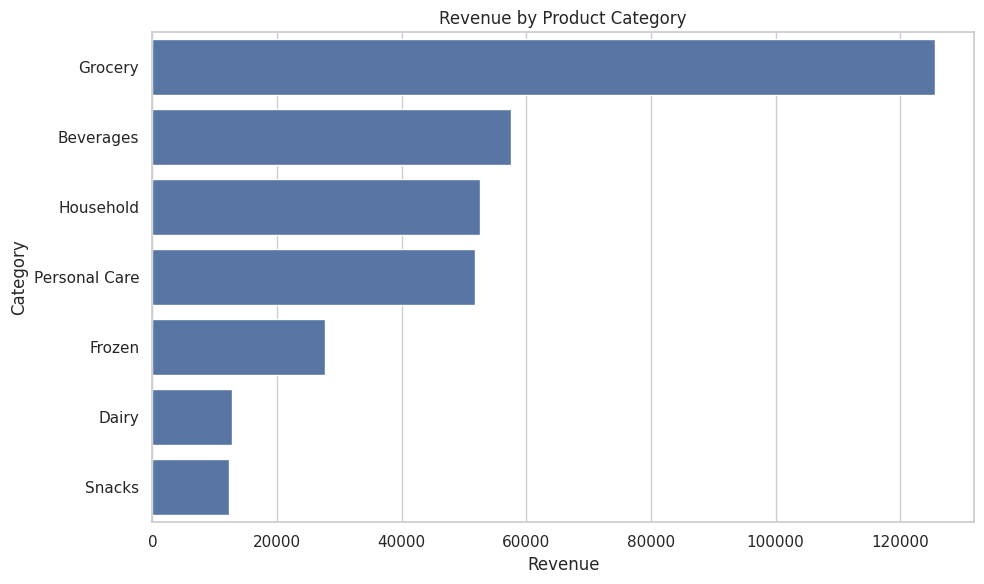

In [31]:
# ============================================================
# EDA 1
# BUSINESS QUESTION:
# Which product categories generate the most revenue?
# ============================================================

category_revenue = (
    master
    .groupby("category", as_index=False)
    ["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
)

display(category_revenue)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_revenue,
    x="revenue",
    y="category"
)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_PATH,
        "01_revenue_by_category.png"
    ),
    dpi=300
)

plt.show()

In [32]:
# ============================================================
# EDA 2
# BUSINESS QUESTION:
# Which categories contribute most of the total revenue?
# ============================================================

pareto = category_revenue.copy()

pareto["revenue_pct"] = (
    pareto["revenue"] /
    pareto["revenue"].sum()
) * 100

pareto["cumulative_pct"] = (
    pareto["revenue_pct"].cumsum()
)

display(pareto)

,category,revenue,revenue_pct,cumulative_pct
3,Grocery,125565.40,36.885939,36.885939
0,Beverages,57612.49,16.924175,53.810115
4,Household,52582.89,15.446686,69.256801
5,Personal Care,51827.29,15.224722,84.481522
2,Frozen,27659.45,8.125206,92.606729
1,Dairy,12841.48,3.772298,96.379026
6,Snacks,12326.35,3.620974,100.000000


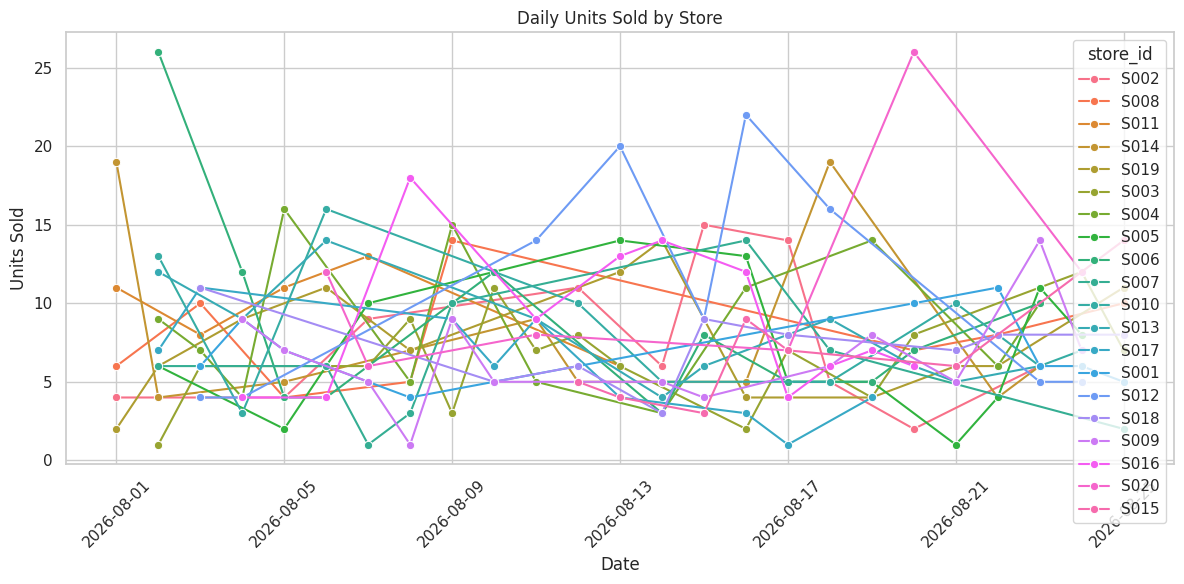

In [33]:
# ============================================================
# EDA 3
# BUSINESS QUESTION:
# Which stores are growing or declining over time?
# ============================================================

store_daily = (
    master
    .groupby(
        ["date", "store_id"],
        as_index=False
    )
    ["units_sold"]
    .sum()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=store_daily,
    x="date",
    y="units_sold",
    hue="store_id",
    marker="o"
)

plt.title("Daily Units Sold by Store")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_PATH,
        "02_store_sales_trend.png"
    ),
    dpi=300
)

plt.show()


,promotion_flag,units_sold,promotion_status
0,0,5.353659,No Promotion
1,1,8.012346,Promotion


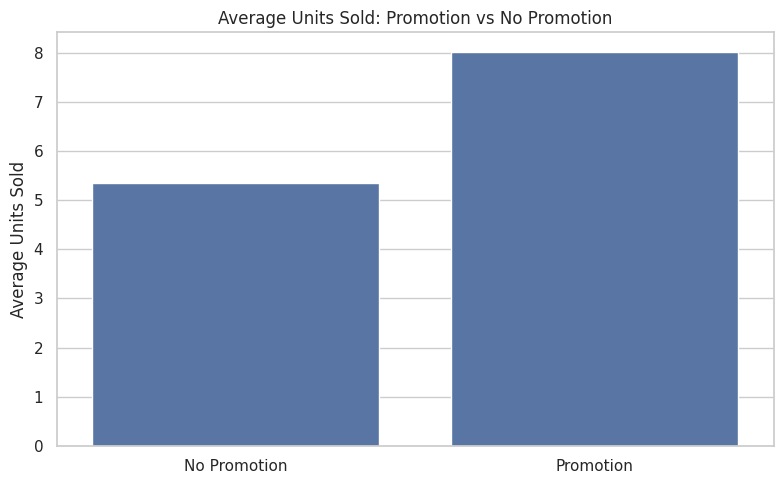

In [34]:
# ============================================================
# EDA 4
# BUSINESS QUESTION:
# Do promotional periods generate higher unit sales?
# ============================================================

promotion_sales = (
    master
    .groupby("promotion_flag")
    ["units_sold"]
    .mean()
    .reset_index()
)

promotion_sales["promotion_status"] = (
    promotion_sales["promotion_flag"]
    .map({
        0: "No Promotion",
        1: "Promotion"
    })
)

display(promotion_sales)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=promotion_sales,
    x="promotion_status",
    y="units_sold"
)

plt.title("Average Units Sold: Promotion vs No Promotion")
plt.xlabel("")
plt.ylabel("Average Units Sold")

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_PATH,
        "03_promotion_vs_nonpromotion.png"
    ),
    dpi=300
)

plt.show()

,weekend_flag,units_sold,period
0,0,5.923529,Weekday
1,1,6.933333,Weekend


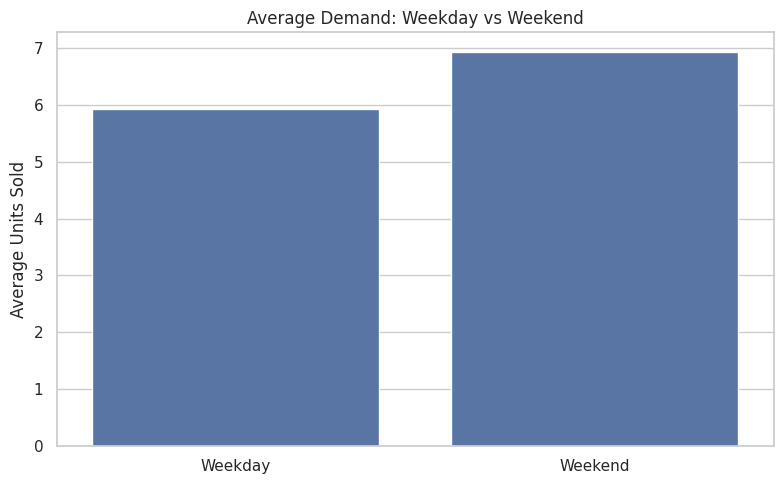

In [35]:
# ============================================================
# EDA 5
# BUSINESS QUESTION:
# How does weekend demand differ from weekday demand?
# ============================================================

weekend_sales = (
    master
    .groupby("weekend_flag")
    ["units_sold"]
    .mean()
    .reset_index()
)

weekend_sales["period"] = (
    weekend_sales["weekend_flag"]
    .map({
        0: "Weekday",
        1: "Weekend"
    })
)

display(weekend_sales)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=weekend_sales,
    x="period",
    y="units_sold"
)

plt.title("Average Demand: Weekday vs Weekend")
plt.xlabel("")
plt.ylabel("Average Units Sold")

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_PATH,
        "04_weekday_vs_weekend.png"
    ),
    dpi=300
)

plt.show()

In [37]:
# ============================================================
# EDA 6
# BUSINESS QUESTION:
# Which products have highly volatile demand?
# ============================================================

product_volatility = (
    master
    .groupby("product_id")
    ["units_sold"]
    .agg(
        mean_demand="mean",
        std_demand="std"
    )
    .reset_index()
)

# Coefficient of Variation
product_volatility["coefficient_of_variation"] = (
    product_volatility["std_demand"] /
    product_volatility["mean_demand"].replace(0, np.nan)
)

product_volatility = (
    product_volatility
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values(
        "coefficient_of_variation",
        ascending=False
    )
)

display(product_volatility.head(10))

,product_id,mean_demand,std_demand,coefficient_of_variation
18,P019,6.142857,4.140393,0.674018
17,P018,5.000000,3.286335,0.657267
26,P027,6.625000,3.925648,0.592551
8,P009,5.400000,3.134042,0.580378
2,P003,6.333333,3.674235,0.580142
19,P020,6.400000,3.646917,0.569831
9,P010,5.375000,2.973094,0.553134
27,P028,6.333333,3.472838,0.548343
25,P026,5.222222,2.635231,0.504619
22,P023,6.000000,3.000000,0.500000


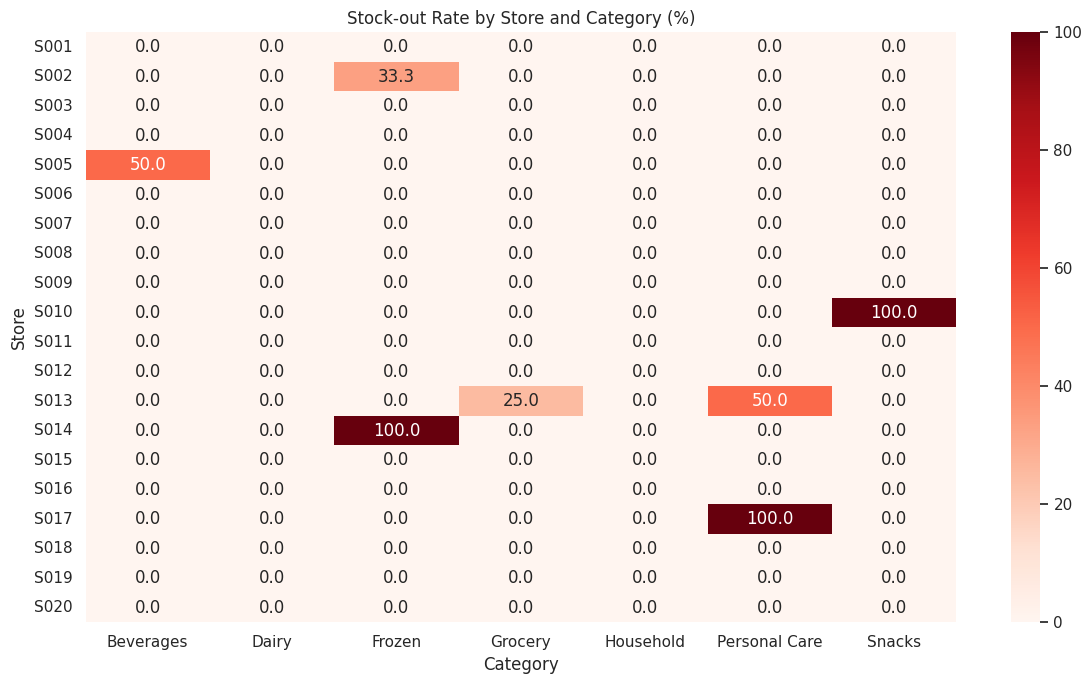

In [38]:
# ============================================================
# EDA 7
# BUSINESS QUESTION:
# Which stores repeatedly experience stock-out risk?
# ============================================================

stockout_heatmap = pd.pivot_table(
    master,
    values="stockout_flag",
    index="store_id",
    columns="category",
    aggfunc="mean",
    fill_value=0
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    stockout_heatmap * 100,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Stock-out Rate by Store and Category (%)")
plt.xlabel("Category")
plt.ylabel("Store")

plt.tight_layout()

plt.savefig(
    os.path.join(
        CHART_PATH,
        "05_stockout_heatmap.png"
    ),
    dpi=300
)

plt.show()

In [39]:
# ============================================================
# BUSINESS KPI CALCULATIONS
# ============================================================

total_revenue = master["revenue"].sum()

total_units = master["units_sold"].sum()

stockout_rate = (
    master["stockout_flag"].mean() * 100
)

inventory_value = (
    master["closing"] *
    master["cost_price"]
).sum()

average_inventory_value = (
    master["closing"] *
    master["cost_price"]
).mean()

average_daily_demand = (
    master["units_sold"].mean()
)

print("STOCKSENSE BUSINESS KPIs")
print("=" * 50)

print(
    f"Total Revenue       : ₹{total_revenue:,.2f}"
)

print(
    f"Total Units Sold    : {total_units:,.0f}"
)

print(
    f"Stock-out Rate      : {stockout_rate:.2f}%"
)

print(
    f"Inventory Value     : ₹{inventory_value:,.2f}"
)

print(
    f"Average Demand      : {average_daily_demand:.2f}"
)

STOCKSENSE BUSINESS KPIs
Total Revenue       : ₹365,310.82
Total Units Sold    : 1,527
Stock-out Rate      : 2.86%
Inventory Value     : ₹12,902,881.49
Average Demand      : 6.23


In [40]:
# ============================================================
# STATISTICAL TEST 1
#
# BUSINESS QUESTION:
# Do promotions significantly increase units sold?
#
# H0:
# Mean units sold during promotion =
# Mean units sold without promotion
#
# H1:
# Mean units sold during promotion !=
# Mean units sold without promotion
# ============================================================

promotion_group = master[
    master["promotion_flag"] == 1
]["units_sold"]

non_promotion_group = master[
    master["promotion_flag"] == 0
]["units_sold"]

t_stat, p_value = stats.ttest_ind(
    promotion_group,
    non_promotion_group,
    equal_var=False
)

print("STATISTICAL TEST 1")
print("=" * 50)

print("Test: Independent Samples t-test")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:

    print(
        "Result: Statistically significant difference "
        "at the 5% significance level."
    )

else:

    print(
        "Result: No statistically significant difference "
        "at the 5% significance level."
    )

STATISTICAL TEST 1
Test: Independent Samples t-test
T-statistic: 7.5292
P-value: 0.000000
Result: Statistically significant difference at the 5% significance level.


In [41]:
# ============================================================
# STATISTICAL TEST 2
#
# BUSINESS QUESTION:
# Does mean demand differ across store types?
#
# H0:
# All store types have the same mean demand.
#
# H1:
# At least one store type has a different mean demand.
# ============================================================

store_type_groups = []

store_types = master["store_type"].dropna().unique()

for store_type in store_types:

    group = master[
        master["store_type"] == store_type
    ]["units_sold"]

    store_type_groups.append(group)

f_stat, p_value_anova = stats.f_oneway(
    *store_type_groups
)

print("STATISTICAL TEST 2")
print("=" * 50)

print("Test: One-way ANOVA")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value_anova:.6f}")

if p_value_anova < 0.05:

    print(
        "Result: Mean demand differs significantly "
        "across at least one store type."
    )

else:

    print(
        "Result: No statistically significant evidence "
        "of different mean demand across store types."
    )

STATISTICAL TEST 2
Test: One-way ANOVA
F-statistic: 0.5848
P-value: 0.558106
Result: No statistically significant evidence of different mean demand across store types.


In [42]:
# ============================================================
# STATISTICAL TEST 3
#
# BUSINESS QUESTION:
# Is stock-out frequency associated with promotion status?
#
# H0:
# Promotion status and stock-out occurrence are independent.
#
# H1:
# Promotion status and stock-out occurrence are associated.
# ============================================================

contingency_table = pd.crosstab(
    master["promotion_flag"],
    master["stockout_flag"]
)

print("CONTINGENCY TABLE")
display(contingency_table)

chi2, p_value_chi, dof, expected = (
    stats.chi2_contingency(contingency_table)
)

print("\nSTATISTICAL TEST 3")
print("=" * 50)

print("Test: Chi-square Test of Independence")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value_chi:.6f}")

if p_value_chi < 0.05:

    print(
        "Result: Promotion status and stock-out occurrence "
        "show a statistically significant association."
    )

else:

    print(
        "Result: No statistically significant association "
        "was detected between promotion status and stock-out."
    )

CONTINGENCY TABLE


stockout_flag,0,1
promotion_flag,,
0,159,5
1,79,2



STATISTICAL TEST 3
Test: Chi-square Test of Independence
Chi-square statistic: 0.0000
P-value: 1.000000
Result: No statistically significant association was detected between promotion status and stock-out.


In [43]:
# ============================================================
# STATISTICAL TEST 3
#
# BUSINESS QUESTION:
# Is stock-out frequency associated with promotion status?
#
# H0:
# Promotion status and stock-out occurrence are independent.
#
# H1:
# Promotion status and stock-out occurrence are associated.
# ============================================================

contingency_table = pd.crosstab(
    master["promotion_flag"],
    master["stockout_flag"]
)

print("CONTINGENCY TABLE")
display(contingency_table)

chi2, p_value_chi, dof, expected = (
    stats.chi2_contingency(contingency_table)
)

print("\nSTATISTICAL TEST 3")
print("=" * 50)

print("Test: Chi-square Test of Independence")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value_chi:.6f}")

if p_value_chi < 0.05:

    print(
        "Result: Promotion status and stock-out occurrence "
        "show a statistically significant association."
    )

else:

    print(
        "Result: No statistically significant association "
        "was detected between promotion status and stock-out."
    )

CONTINGENCY TABLE


stockout_flag,0,1
promotion_flag,,
0,159,5
1,79,2



STATISTICAL TEST 3
Test: Chi-square Test of Independence
Chi-square statistic: 0.0000
P-value: 1.000000
Result: No statistically significant association was detected between promotion status and stock-out.


In [45]:
# ============================================================
# SAVE STATISTICAL ANALYSIS REPORT
# ============================================================

# Create a summary table for all 3 statistical tests
statistical_results = pd.DataFrame({

    "Business_Question": [
        "Do promotions significantly increase sales?",
        "Does mean demand differ across store types?",
        "Is stock-out frequency associated with promotion status?"
    ],

    "Null_Hypothesis_H0": [
        "Mean sales are the same for promotion and non-promotion periods",
        "Mean demand is the same across all store types",
        "Promotion status and stock-out occurrence are independent"
    ],

    "Alternative_Hypothesis_H1": [
        "Mean sales differ between promotion and non-promotion periods",
        "At least one store type has different mean demand",
        "Promotion status and stock-out occurrence are associated"
    ],

    "Test_Used": [
        "Independent Samples t-test",
        "One-way ANOVA",
        "Chi-square Test of Independence"
    ],

    "Statistic": [
        t_stat,
        f_stat,
        chi2
    ],

    "P_Value": [
        p_value,
        p_value_anova,
        p_value_chi
    ]
})

# Add statistical conclusion automatically
statistical_results["Conclusion"] = statistical_results["P_Value"].apply(
    lambda p:
    "Reject H0 - Statistically Significant"
    if p < 0.05
    else "Fail to Reject H0 - Not Statistically Significant"
)

# Make sure reports folder exists
os.makedirs(REPORT_PATH, exist_ok=True)

# Full file path
STAT_REPORT_PATH = os.path.join(
    REPORT_PATH,
    "statistical_analysis_results.csv"
)

# Save CSV
statistical_results.to_csv(
    STAT_REPORT_PATH,
    index=False
)

print("✅ Statistical report saved successfully!")
print("Location:", STAT_REPORT_PATH)

display(statistical_results)

✅ Statistical report saved successfully!
Location: /content/drive/MyDrive/STOCKSENSE_TEAM_NEXUS/reports/statistical_analysis_results.csv


,Business_Question,Null_Hypothesis_H0,Alternative_Hypothesis_H1,Test_Used,Statistic,P_Value,Conclusion
0,Do promotions significantly increase sales?,Mean sales are the same for promotion and non-...,Mean sales differ between promotion and non-pr...,Independent Samples t-test,7.529210,5.544451e-12,Reject H0 - Statistically Significant
1,Does mean demand differ across store types?,Mean demand is the same across all store types,At least one store type has different mean demand,One-way ANOVA,0.584762,5.581062e-01,Fail to Reject H0 - Not Statistically Significant
2,Is stock-out frequency associated with promoti...,Promotion status and stock-out occurrence are ...,Promotion status and stock-out occurrence are ...,Chi-square Test of Independence,0.000000,1.000000e+00,Fail to Reject H0 - Not Statistically Significant


In [46]:
# ============================================================
# VERIFY REPORT FILE
# ============================================================

print("Files currently inside reports folder:\n")

for file in os.listdir(REPORT_PATH):
    print("✔", file)

print("\nStatistical report exists:",
      os.path.exists(STAT_REPORT_PATH))

Files currently inside reports folder:

✔ data_quality_report.csv
✔ category_revenue_analysis.csv
✔ product_volatility.csv
✔ business_kpis.csv
✔ statistical_analysis_results.csv

Statistical report exists: True


In [47]:
# ============================================================
# FINAL ROUND 1 SAVE
# ============================================================

# Save master dataset
master.to_csv(
    os.path.join(
        PROCESSED_PATH,
        "master_cleaned.csv"
    ),
    index=False
)

# Save category analysis
category_revenue.to_csv(
    os.path.join(
        REPORT_PATH,
        "category_revenue_analysis.csv"
    ),
    index=False
)

# Save product volatility
product_volatility.to_csv(
    os.path.join(
        REPORT_PATH,
        "product_volatility.csv"
    ),
    index=False
)

# Save KPI summary
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Units Sold",
        "Stock-out Rate",
        "Inventory Value",
        "Average Daily Demand"
    ],
    "Value": [
        total_revenue,
        total_units,
        stockout_rate,
        inventory_value,
        average_daily_demand
    ]
})

kpi_summary.to_csv(
    os.path.join(
        REPORT_PATH,
        "business_kpis.csv"
    ),
    index=False
)

print("All Round 1 outputs saved successfully!")

All Round 1 outputs saved successfully!
